# Emotion Classification in Cartoon Faces (Tom & Jerry) – Improved Model

This notebook presents an improved image classification pipeline for recognizing emotions in cartoon characters (Tom & Jerry).

Compared to the initial version, this model uses more advanced feature extraction techniques, feature scaling, and dimensionality reduction, leading to a more expressive and compact representation of facial emotions.

The main steps of the pipeline are:
- Image preprocessing and normalization
- Feature extraction using texture, shape, and frequency information
- Feature scaling and dimensionality reduction with PCA
- Emotion classification using an improved K-Nearest Neighbors (KNN)
- Evaluation using accuracy, confusion matrices, and visual inspection of predictions

The notebook also includes visualizations of intermediate features to better understand how images are represented.

In [133]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from skimage.feature import hog, local_binary_pattern
import seaborn as sns
import pandas as pd

In [134]:
DATA_DIR = "emotion_dataset"
IMG_SIZE = (64, 64)

LBP_RADIUS = 2
LBP_POINTS = 8 * LBP_RADIUS

PCA_COMPONENTS = 0.95   # keep 95% variance

## Preprocessing

Each image is preprocessed to ensure consistency and improve feature quality:

- **Resizing**: all images are resized to a fixed resolution (64×64)
- **Grayscale conversion**: simplifies the data and focuses on structure
- **Gaussian blur**: reduces small noise and artifacts
- **CLAHE (Contrast Limited Adaptive Histogram Equalization)**: improves local contrast
- **Normalization**: pixel values are scaled to the range [0, 1]

This preprocessing step helps make the extracted features more robust to lighting and contrast variations.

In [135]:
def preprocess_image(image):
    image = cv2.resize(image, IMG_SIZE)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image = cv2.GaussianBlur(image, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)

    image = image.astype(np.float32) / 255.0
    return image

## Feature Extraction

To better capture facial expressions, multiple complementary feature types are extracted from each image:

1. **Histogram of Oriented Gradients (HOG)**
   Captures edge directions and local shape information, which is useful for facial structure.

2. **Local Binary Patterns (LBP)**
   Describes local texture patterns and is effective for capturing fine facial details.

3. **Fourier Transform (Low Frequencies)**
   Represents global frequency information and overall facial layout.

4. **Gabor Filter Responses**
   Extracts texture information at different orientations, mimicking human visual perception.

By combining these features, the model captures shape, texture, and global structure in a single feature vector.

In [136]:
def extract_features(image):
    features = []

    # HOG
    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    features.extend(hog_features)

    # LBP (uniform)
    image_uint8 = (image * 255).astype(np.uint8)

    lbp = local_binary_pattern(
        image_uint8,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method="uniform"
    )
    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, LBP_POINTS + 3),
        density=True
    )
    features.extend(lbp_hist)

    # Fourier (central low frequencies)
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(1 + np.abs(fshift))

    h, w = magnitude.shape
    center = magnitude[h//2-6:h//2+6, w//2-6:w//2+6]
    features.extend(center.flatten())

    # Gabor filters (multiple orientations)
    for theta in [0, np.pi/4, np.pi/2]:
        kernel = cv2.getGaborKernel(
            (9, 9),
            sigma=3.0,
            theta=theta,
            lambd=8.0,
            gamma=0.5
        )
        filtered = cv2.filter2D(image, cv2.CV_32F, kernel)
        features.append(filtered.mean())
        features.append(filtered.var())

    return np.array(features, dtype=np.float64)

## Feature Visualization

To better understand what the model “sees”, several feature representations are visualized for sample images:

- Original image
- Preprocessed image
- HOG visualization
- LBP pattern image
- Fourier magnitude spectrum
- Gabor filter response
- Sobel edges (for comparison)

These visualizations help illustrate how different feature extractors highlight different aspects of facial expressions.

In [137]:
def visualize_features(image, idx=0):
    pre = preprocess_image(image)

    # HOG visualization
    hog_feats, hog_img = hog(
        pre,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm="L2-Hys"
    )

    # LBP
    image_uint8 = (pre * 255).astype(np.uint8)

    lbp = local_binary_pattern(
        image_uint8,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method="uniform"
    )

    # Fourier
    f = np.fft.fftshift(np.fft.fft2(pre))
    fourier_mag = np.log(1 + np.abs(f))

    # Gabor (one orientation example)
    kernel = cv2.getGaborKernel((9,9), 3.0, 0, 8.0, 0.5)
    gabor = cv2.filter2D(pre, cv2.CV_32F, kernel)

    # Sobel (optional)
    sobel_x = cv2.Sobel(pre, cv2.CV_32F, 1, 0)
    sobel_y = cv2.Sobel(pre, cv2.CV_32F, 0, 1)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)

    images = [
        image, pre, hog_img, lbp, fourier_mag, gabor, sobel
    ]
    titles = [
        "Original", "Preprocessed", "HOG",
        "LBP", "Fourier", "Gabor", "Sobel"
    ]

    plt.figure(figsize=(16, 6))
    for i, (img, t) in enumerate(zip(images, titles)):
        plt.subplot(2, 4, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(t)
        plt.axis("off")

    plt.suptitle(f"Sample Image {idx}")
    plt.tight_layout()
    plt.show()

In [138]:
def visualize_one_sample_per_emotion(
    character_dir,
    visualize_fn,
    max_per_emotion=1
):
    """
    Visualize one sample image per emotion for a given character.
    """
    emotion_labels = sorted(
        [d for d in os.listdir(character_dir)
         if os.path.isdir(os.path.join(character_dir, d))]
    )

    for emotion in emotion_labels:
        folder = os.path.join(character_dir, emotion)

        for i, filename in enumerate(os.listdir(folder)):
            if i >= max_per_emotion:
                break

            img_path = os.path.join(folder, filename)

            original = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if original is None:
                continue

            # Convert BGR -> RGB for matplotlib
            original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

            print(f"{os.path.basename(character_dir)} - {emotion}")
            visualize_fn(original, idx=f"{emotion}")

tom - angry


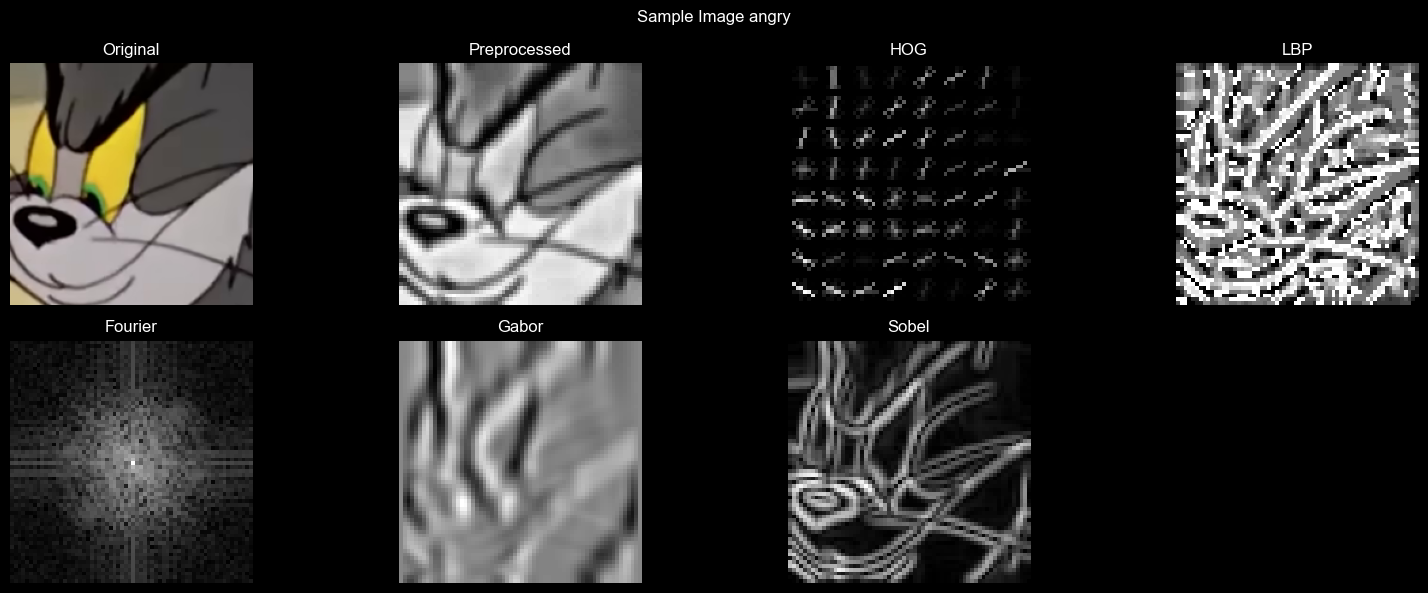

tom - happy


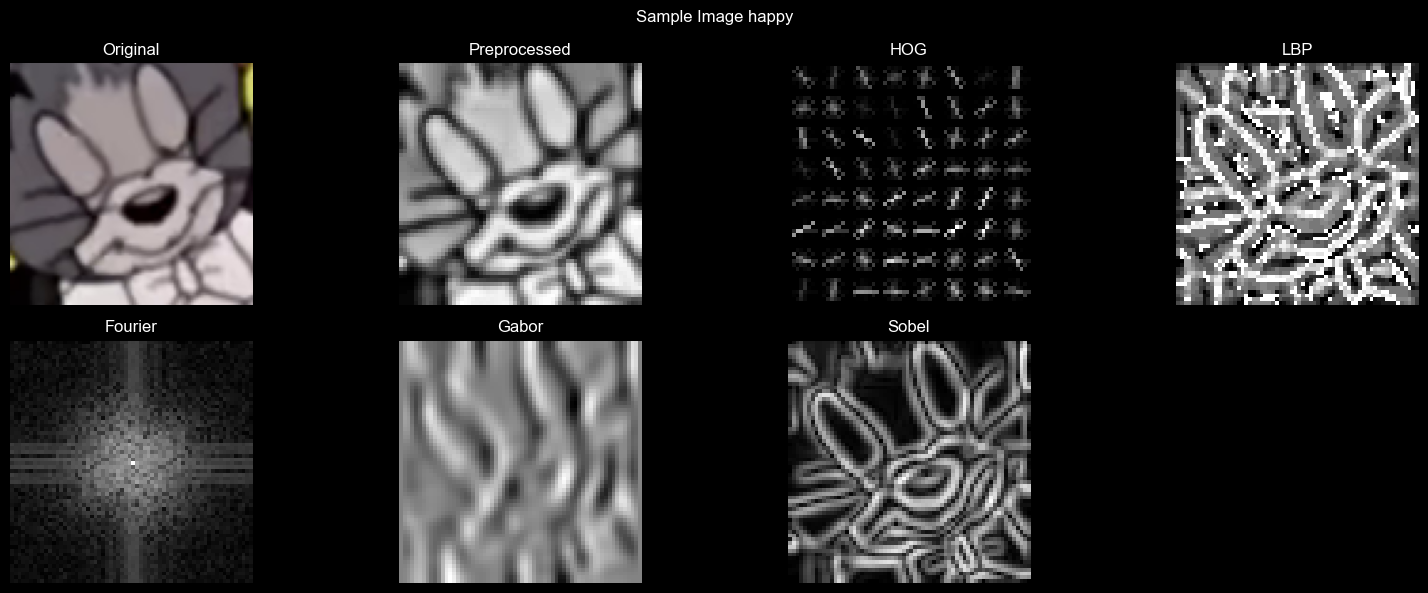

tom - surprised


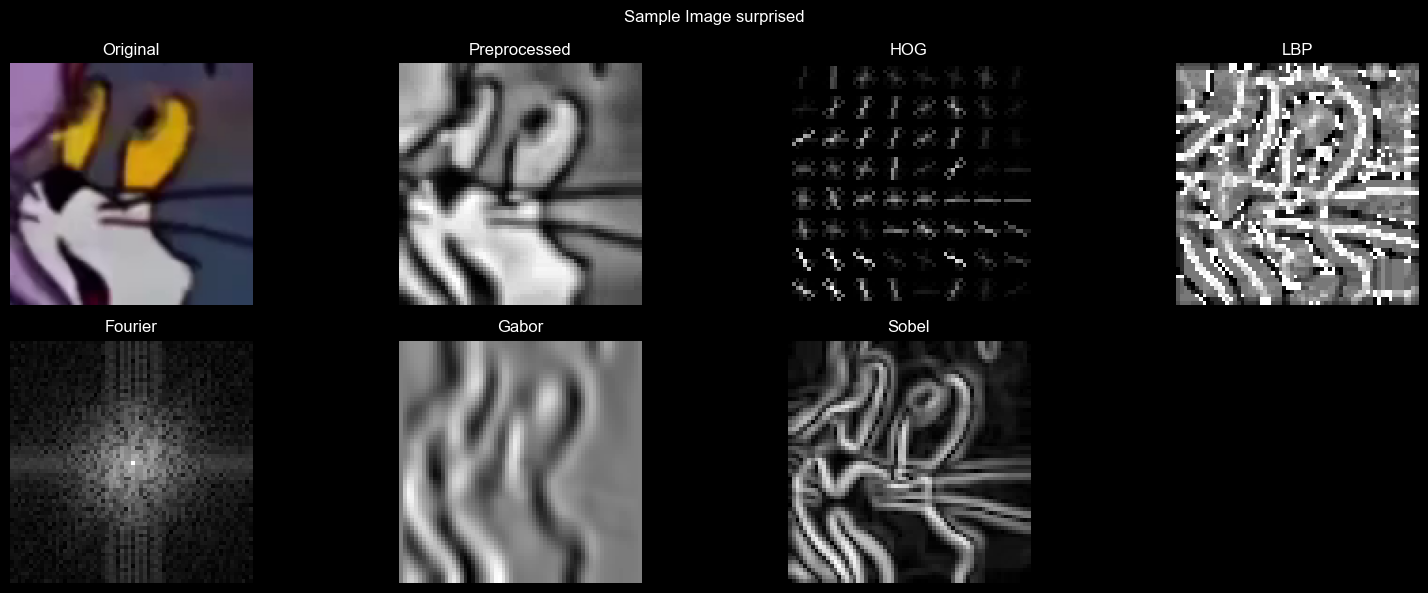

In [139]:
visualize_one_sample_per_emotion(
    character_dir="emotion_dataset/tom",
    visualize_fn=visualize_features
)

jerry - angry


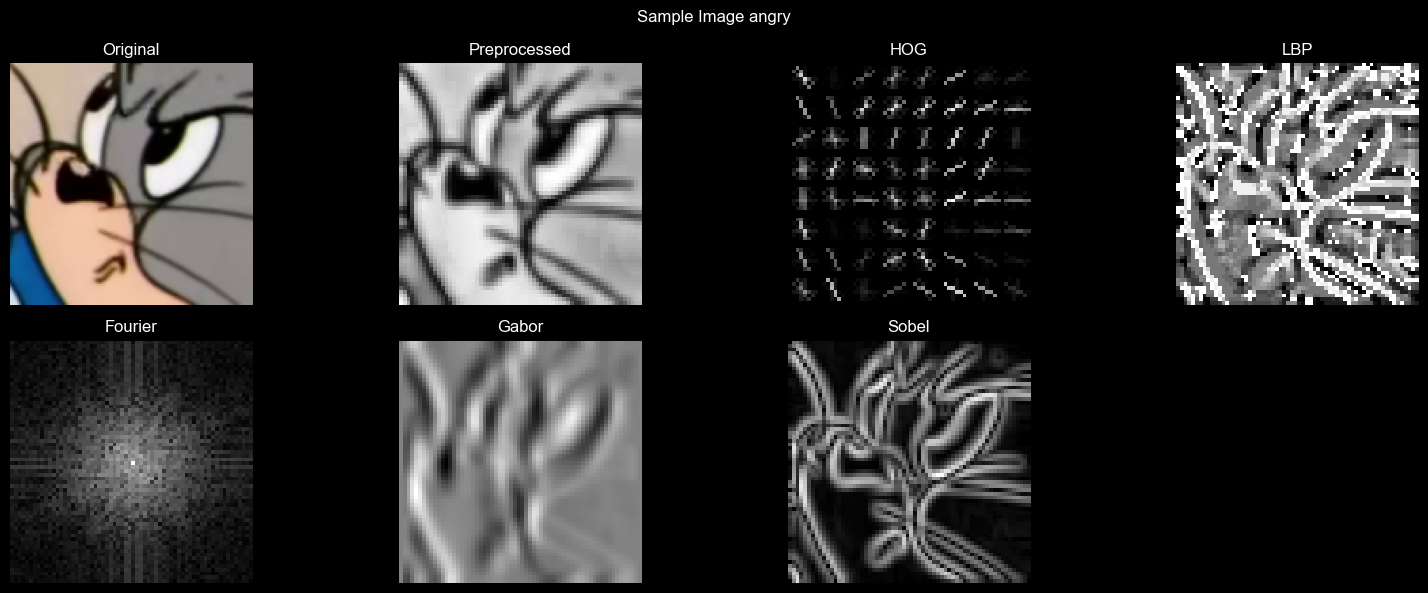

jerry - happy


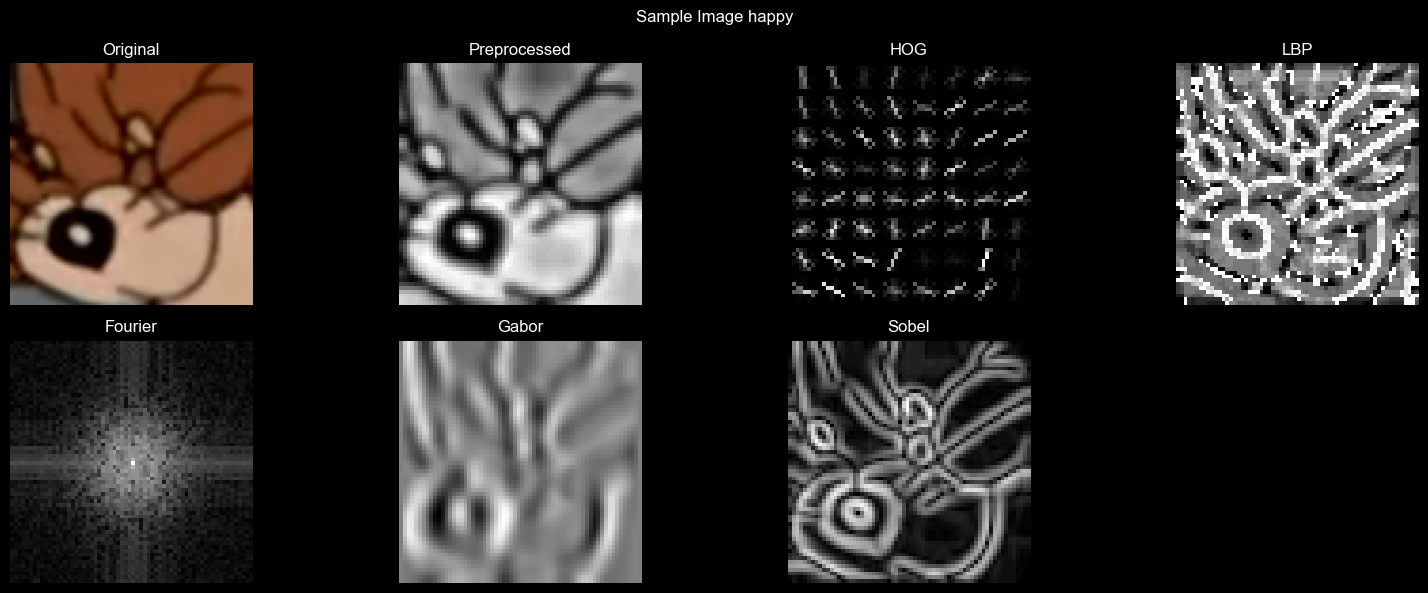

jerry - surprised


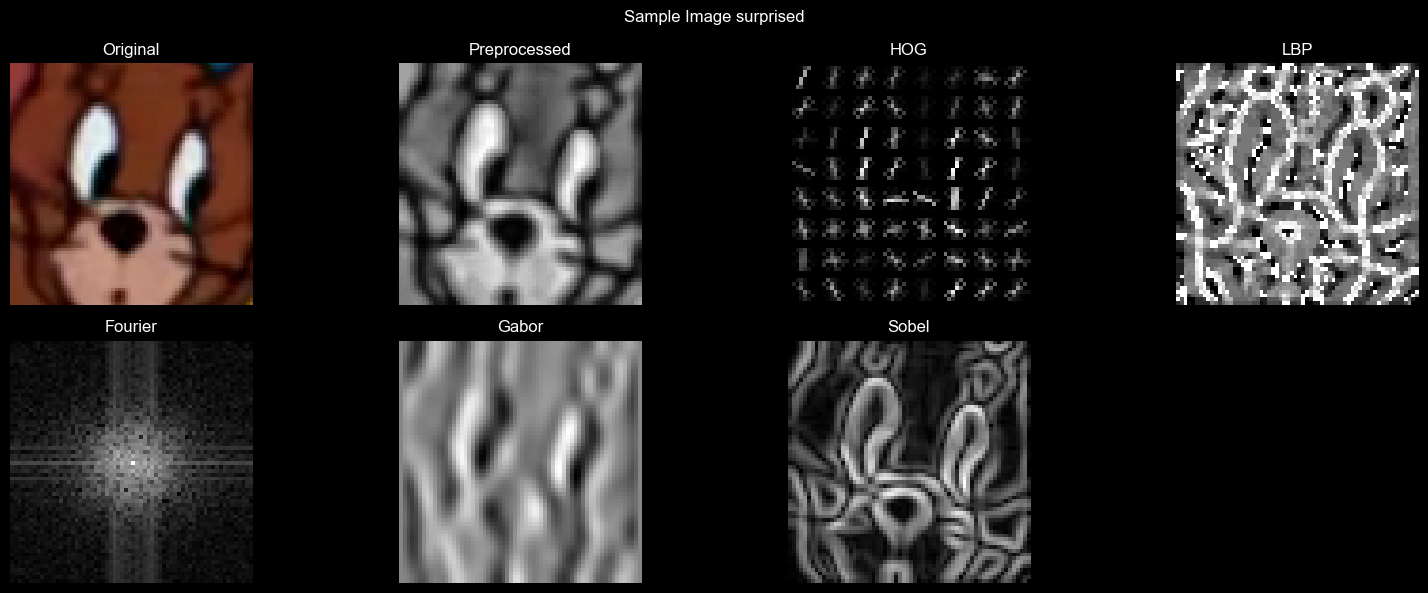

In [140]:
visualize_one_sample_per_emotion(
    character_dir="emotion_dataset/jerry",
    visualize_fn=visualize_features
)

## Dataset Loading and Feature Extraction

The dataset is organized by character and emotion label.

For each image:
- The image is preprocessed
- Features are extracted
- The corresponding emotion label is assigned

The result is a feature matrix, a label vector, and a list of image paths for later visualization.

In [141]:
def load_character_data(character_dir):
    features_list = []
    labels = []
    image_paths = []

    emotion_names = sorted(
        [d for d in os.listdir(character_dir) if os.path.isdir(os.path.join(character_dir, d))]
    )
    label_to_index = {name: idx for idx, name in enumerate(emotion_names)}

    for emotion in emotion_names:
        folder = os.path.join(character_dir, emotion)
        label_idx = label_to_index[emotion]

        for filename in os.listdir(folder):
            img_path = os.path.join(folder, filename)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)

            if image is None:
                continue

            preprocessed = preprocess_image(image)
            features = extract_features(preprocessed)

            features_list.append(features)
            labels.append(label_idx)
            image_paths.append(img_path)

    return (
        np.array(features_list),
        np.array(labels),
        image_paths,
        emotion_names
    )

print("Loading and processing Tom dataset...")
X_tom, y_tom, tom_paths, tom_labels = load_character_data("emotion_dataset/tom")
print("Feature vector size:", X_tom.shape[1])

print()

print("Loading and processing Jerry dataset...")
X_jerry, y_jerry, jerry_paths, jerry_labels = load_character_data("emotion_dataset/jerry")
print("Feature vector size:", X_jerry.shape[1])

Loading and processing Tom dataset...
Feature vector size: 1932

Loading and processing Jerry dataset...
Feature vector size: 1932


## Data Preparation: Scaling and PCA

Before classification, additional preprocessing steps are applied:

- **Standardization**: features are scaled to zero mean and unit variance
- **Principal Component Analysis (PCA)**: reduces dimensionality while preserving 95% of the variance

PCA helps reduce redundancy in the feature space, speeds up computation, and improves KNN performance.

In [142]:
def prepare_data(X, y, paths):
    X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
        X, y, paths,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pca = PCA(
        n_components=PCA_COMPONENTS,
        svd_solver="auto",
        random_state=42,
    )
    X_train = pca.fit_transform(X_train)

    X_test = pca.transform(X_test)

    print(f"PCA kept {X_train.shape[1]} components "
          f"({100*pca.explained_variance_ratio_.sum():.1f}% variance)")

    return X_train, X_test, y_train, y_test, train_paths, test_paths

In [143]:
X_tom_train, X_tom_test, y_tom_train, y_tom_test, tom_train_paths, tom_test_paths = prepare_data(X_tom, y_tom, tom_paths)

X_jerry_train, X_jerry_test, y_jerry_train, y_jerry_test, jerry_train_paths, jerry_test_paths = prepare_data(X_jerry, y_jerry, jerry_paths)

PCA kept 294 components (95.1% variance)
PCA kept 264 components (95.1% variance)


## K-Nearest Neighbors Classification

Emotion classification is performed using a manually implemented KNN classifier with improvements over the initial model:

- Support for different distance metrics (Euclidean and Manhattan)
- Distance-weighted voting
- Hyperparameter exploration for different values of *k*

Cross-validation is used to compare different configurations and select suitable parameters.

In [144]:
def knn_predict(X_train, y_train, x, k, metric="euclidean"):
    if metric == "manhattan":
        dists = np.sum(np.abs(X_train - x), axis=1)
    else:
        dists = np.linalg.norm(X_train - x, axis=1)

    idx = np.argsort(dists)[:k]
    weights = 1 / (dists[idx] + 1e-8)

    votes = {}
    for label, w in zip(y_train[idx], weights):
        votes[label] = votes.get(label, 0) + w

    return max(votes, key=votes.get)

In [145]:
def knn_predict_batch(X_train, y_train, X_test, k, metric):
    return np.array([
        knn_predict(X_train, y_train, x, k, metric)
        for x in X_test
    ])

In [146]:
def cross_validate_knn(X_train, y_train, X_test, y_test, k_values, metrics):
    results = []

    for k in k_values:
        for metric in metrics:
            scores = []

            preds = knn_predict_batch(X_train, y_train, X_test, k, metric)
            scores.append(accuracy_score(y_test, preds))

            results.append({
                "k": k,
                "metric": metric,
                "mean_accuracy": np.mean(scores)
            })

    return results

In [147]:
results = cross_validate_knn(
    X_tom_train, y_tom_train, X_tom_test, y_tom_test,
    k_values=[3, 5, 7, 9],
    metrics=["euclidean", "manhattan"]
)

df_tom = pd.DataFrame(results)
print(df_tom)

   k     metric  mean_accuracy
0  3  euclidean       0.725000
1  3  manhattan       0.641667
2  5  euclidean       0.741667
3  5  manhattan       0.650000
4  7  euclidean       0.725000
5  7  manhattan       0.650000
6  9  euclidean       0.716667
7  9  manhattan       0.650000


In [148]:
results = cross_validate_knn(
    X_jerry_train, y_jerry_train, X_jerry_test, y_jerry_test,
    k_values=[3, 5, 7, 9],
    metrics=["euclidean", "manhattan"]
)

df_jerry = pd.DataFrame(results)
print(df_jerry)

   k     metric  mean_accuracy
0  3  euclidean       0.761905
1  3  manhattan       0.628571
2  5  euclidean       0.695238
3  5  manhattan       0.676190
4  7  euclidean       0.695238
5  7  manhattan       0.657143
6  9  euclidean       0.685714
7  9  manhattan       0.704762


In [149]:
y_tom_pred = knn_predict_batch(X_tom_train, y_tom_train, X_tom_test, 5, metric="euclidean")
y_jerry_pred = knn_predict_batch(X_jerry_train, y_jerry_train, X_jerry_test, 3, metric="euclidean")

## Model Evaluation

The model is evaluated separately for Tom and Jerry using:

- Overall accuracy
- Classification report (precision, recall, F1-score)
- Confusion matrix visualization

These metrics provide insight into both overall performance and per-emotion classification behavior.

In [150]:
def evaluate_model(y_true, y_pred, label_names, title_prefix=""):
    """
    Evaluate a classifier using accuracy, classification report,
    and confusion matrix visualization.
    """
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"{title_prefix} Model Accuracy: {accuracy * 100:.2f}%\n")

    # Classification report
    print(f"{title_prefix} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.show()

    return accuracy

Tom Model Accuracy: 74.17%

Tom Classification Report:
              precision    recall  f1-score   support

       angry       0.84      0.68      0.75        40
       happy       0.67      0.78      0.72        40
   surprised       0.74      0.78      0.76        40

    accuracy                           0.74       120
   macro avg       0.75      0.74      0.74       120
weighted avg       0.75      0.74      0.74       120



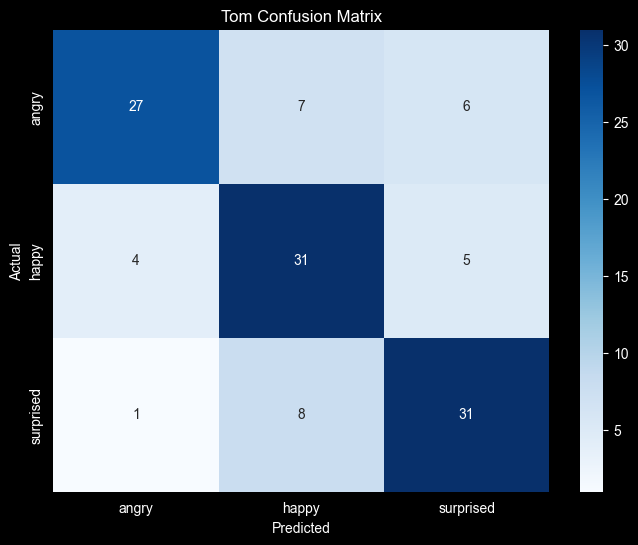

0.7416666666666667

In [151]:
evaluate_model(
    y_true=y_tom_test,
    y_pred=y_tom_pred,
    label_names=tom_labels,
    title_prefix="Tom"
)

Jerry Model Accuracy: 76.19%

Jerry Classification Report:
              precision    recall  f1-score   support

       angry       0.96      0.74      0.84        35
       happy       0.66      0.83      0.73        35
   surprised       0.74      0.71      0.72        35

    accuracy                           0.76       105
   macro avg       0.79      0.76      0.77       105
weighted avg       0.79      0.76      0.77       105



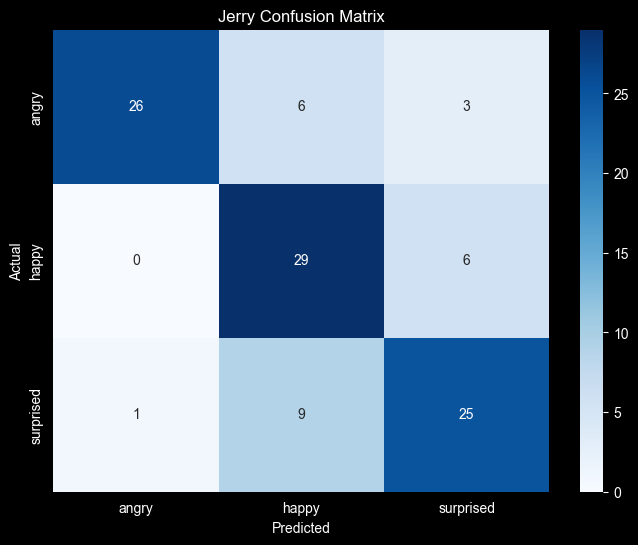

0.7619047619047619

In [152]:
evaluate_model(
    y_true=y_jerry_test,
    y_pred=y_jerry_pred,
    label_names=jerry_labels,
    title_prefix="Jerry"
)

## Sample Predictions

To visually inspect the model’s performance, a selection of test images is displayed with:

- The true emotion label
- The predicted emotion label

This qualitative evaluation helps identify common errors and understand which emotions are harder to classify.

In [153]:
def show_sample_predictions(
    image_paths,
    y_test,
    y_pred,
    label_names,
    num_samples=12,
    title_prefix=""
):
    """
    Visualize sample predictions in a grid layout.
    """
    num_samples = min(num_samples, len(image_paths))

    cols = 4
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    fig.suptitle(f"{title_prefix} - Sample Predictions", fontsize=16, y=0.995)

    # Flatten axes array for easier indexing
    axes = axes.flatten()

    for i in range(num_samples):
        img_path = image_paths[i]

        # Load image
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            continue

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display in subplot
        axes[i].imshow(img)
        axes[i].set_title(
            f"Real: {label_names[y_test[i]]}\nPred: {label_names[y_pred[i]]}",
            fontsize=10
        )
        axes[i].axis('off')

    # Hide any unused subplots
    for i in range(num_samples, rows * cols):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

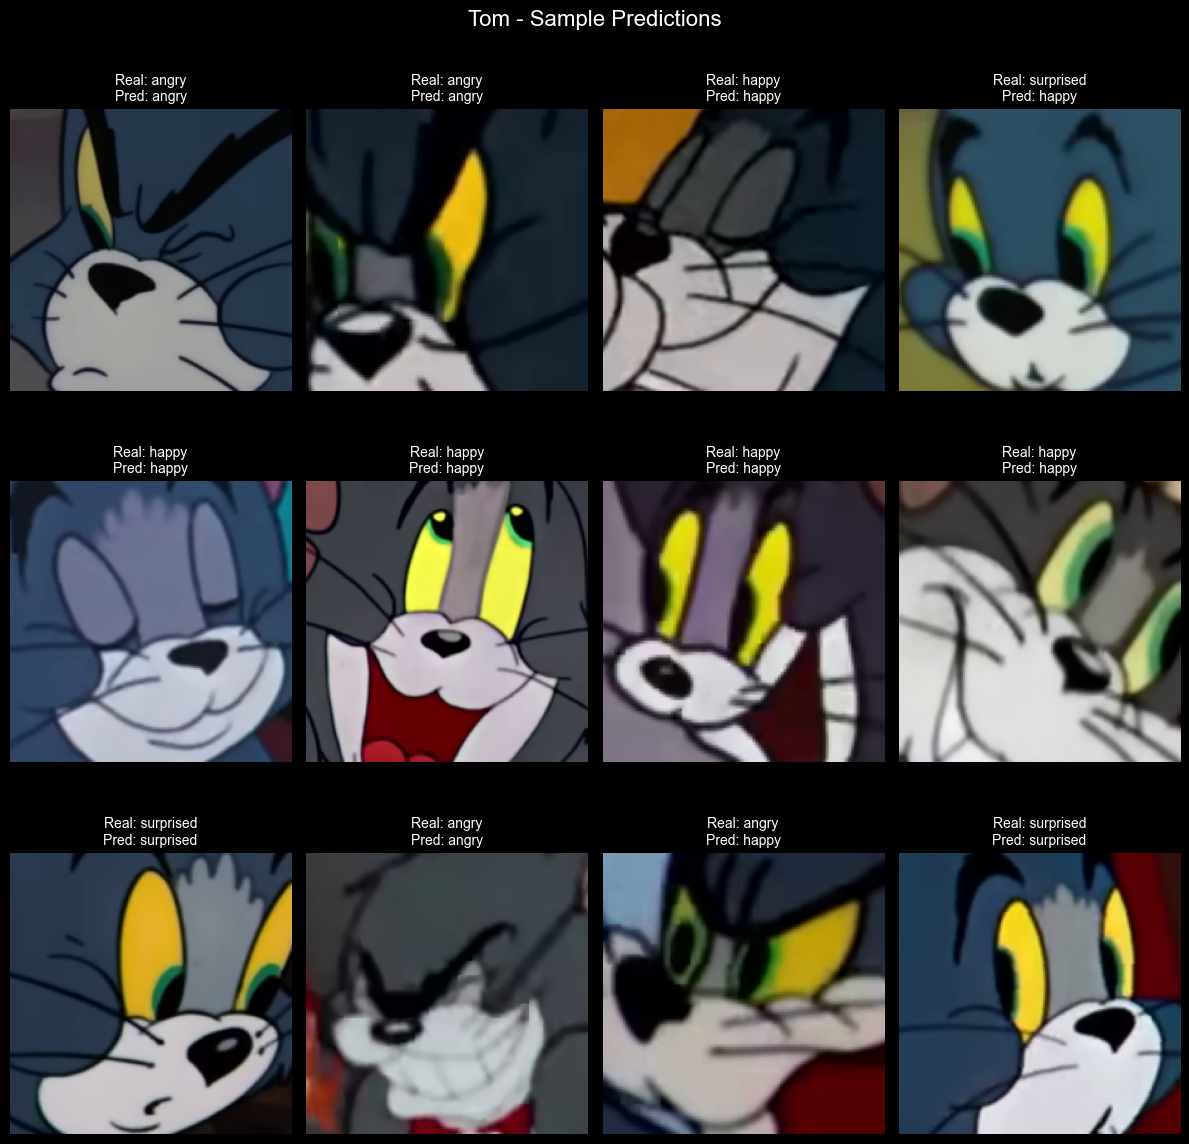

In [154]:
show_sample_predictions(
    image_paths=tom_test_paths,
    y_test=y_tom_test,
    y_pred=y_tom_pred,
    label_names=tom_labels,
    num_samples=12,
    title_prefix="Tom"
)

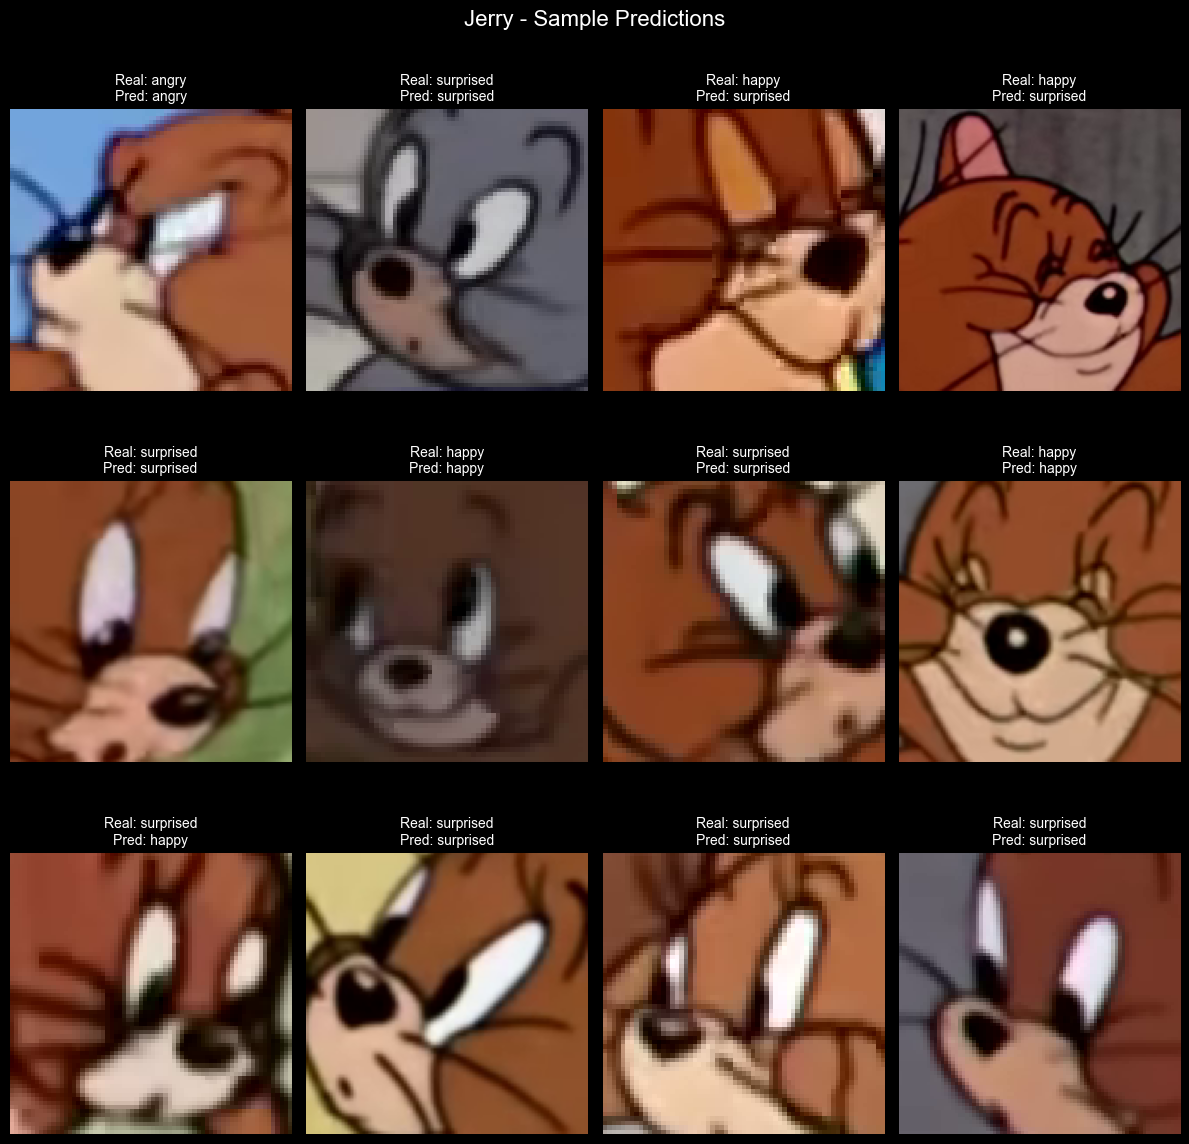

In [155]:
show_sample_predictions(
    image_paths=jerry_test_paths,
    y_test=y_jerry_test,
    y_pred=y_jerry_pred,
    label_names=jerry_labels,
    num_samples=12,
    title_prefix="Jerry"
)